In [1]:
import re
import json
import os
from pathlib import Path
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from typing import List, Literal, Optional
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
%load_ext dotenv
%dotenv

#### Pilicy Text

In [10]:
text= """
Appendix A — Travel Reimbursement Policy 
1. Eligible & Ineligible Categories 
POL-CAT-01 — Eligible categories — Reimbursable when incurred for a documented business purpose: 
- Airfare (economy class only — see POL-AIR-01) 
- Lodging (hotel room charges) 
- Meals (subject to per-diem limits — see POL-PD-01) 
- Ground transport (taxi, rideshare, train, rental car, parking) 
- Conference / registration fees 
POL-CAT-02 — Ineligible items — Never reimbursable; rejected (deducted in full): 
- Alcohol and minibar charges 
- Spa, gym, and personal entertainment 
- In-room movies, personal shopping, gifts 
- Traffic fines, penalties, and late fees 
- Any personal (non-business) expense 
2. Per-Diem & Category Limits 
POL-PD-01 — Meals — Maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed. 
POL-PD-02 — Lodging — Maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed. 
POL-PD-03 — Ground transport — Maximum $50 per day. Amounts above the cap are deducted. 
POL-AIR-01 — Airfare class — Only economy class airfare is reimbursable. Business/first-class fares are a policy exception 
and must be routed to Manual Review (not auto-deducted, because a pre-approval may exist). 
3. Receipt Rules 
POL-RCT-01 — Receipt required above $25 — Any single line item greater than $25 requires an attached, itemized receipt. 
Airfare and lodging always require a receipt regardless of amount. 
POL-RCT-02 — Missing receipt handling — If a receipt is missing for an item that requires one, the item is not silently rejected 
— the claim is routed to Manual Review so the reviewer can request the receipt. 
4. Approval Thresholds 
Thresholds are evaluated on the total reimbursable amount (after per-diem deductions but before final 
decision). 
POL-APR-01 — Auto-approve tier — Total <= $500: may be auto-approved by the agent if fully compliant. 
POL-APR-02 — Manager tier — Total > $500 and <= $2,000: eligible for approval, treated as approvable when fully compliant. 
POL-APR-03 — Director / Manual-Review tier — Total > $2,000: exceeds the agent's auto-approval authority and must be 
routed to Manual Review (director approval required), even if otherwise compliant. 
5. Timeliness 
POL-TIME-01 — Submission window — Claims must be submitted within 30 days of the expense date. Late claims are routed 
to Manual Review.
"""

#### Chunking & Vector db Storing

In [6]:
# Match policy IDs such as POL-CAT-01
pattern = r"(?=POL-[A-Z]+-\d+\s+—)"

sections = re.split(pattern, text)

POLICY_CHUNKS = []

for section in sections:
    section = section.strip()

    if not section:
        continue

    # Extract policy ID
    match = re.search(
        r"(POL-[A-Z]+-\d+)",
        section
    )

    if not match:
        continue

    rule_id = match.group(1)

    # Extract policy category
    category = rule_id.split("-")[1]

    document = Document(
        page_content=section,
        metadata={
            "rule_id": rule_id,
            "category": category,
            # "source": FILE_PATH.name,
            "document_type": "travel_policy",
        },
    )

    POLICY_CHUNKS.append(document)

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
persist_dir = "./chroma_policy_db"

#create or load the persistent database

vector_store = Chroma.from_documents(
    documents=POLICY_CHUNKS, 
    embedding=embedding_model,
    persist_directory=persist_dir
)
print(f"Created and persisted new ChromaDB to {persist_dir}.")

Created and persisted new ChromaDB to ./chroma_policy_db.


In [43]:
vector_store = Chroma(persist_directory = "./chroma_policy_db",
                      collection_name="travel_policy_store",
                     embedding_function = OpenAIEmbeddings(model='text-embedding-3-small'))

In [44]:
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

#### Tool and Structured Output Schema

In [45]:
from langchain_core.tools import tool
from typing import List, Literal
from pydantic import BaseModel, Field
from datetime import datetime

@tool
def lookup_travel_policy(query: str) -> str:
    """Useful to look up specific company reimbursement rules, per-diem caps, or approval thresholds by topic."""
    docs = retriever.invoke(query)
    formatted_docs = [f"[{d.metadata.get('rule_id', 'UNKNOWN')}] (Category: {d.metadata.get('category', 'UNKNOWN')}): {d.page_content}" for d in docs]
    return "\n---\n".join(formatted_docs)

@tool
def audit_expense_limits(category: str, amount: float, days_or_nights: int = 1) -> dict:
    """
    Checks line items against policy caps (POL-PD-01, POL-PD-02, POL-PD-03) and ineligible categories (POL-CAT-02).
    Returns allowed amount, deducted amount, and policy citations.
    """
    cat = category.lower().strip()
    
    if any(item in cat for item in ["spa", "minibar", "entertainment", "movie", "alcohol", "gift"]):
        return {"allowed": 0.0, "deducted": amount, "status": "INELIGIBLE", "rule": "POL-CAT-02"}
    
    if "meal" in cat:
        max_allowed = 75.0 * max(1, days_or_nights)
        if amount > max_allowed:
            return {"allowed": max_allowed, "deducted": round(amount - max_allowed, 2), "status": "EXCEEDED_CAP", "rule": "POL-PD-01"}
        return {"allowed": amount, "deducted": 0.0, "status": "COMPLIANT", "rule": "POL-PD-01"}

    if "lodging" in cat or "hotel" in cat:
        max_allowed = 200.0 * max(1, days_or_nights)
        if amount > max_allowed:
            return {"allowed": max_allowed, "deducted": round(amount - max_allowed, 2), "status": "EXCEEDED_CAP", "rule": "POL-PD-02"}
        return {"allowed": amount, "deducted": 0.0, "status": "COMPLIANT", "rule": "POL-PD-02"}

    if any(item in cat for item in ["transport", "taxi", "rideshare", "rental"]):
        max_allowed = 50.0 * max(1, days_or_nights)
        if amount > max_allowed:
            return {"allowed": max_allowed, "deducted": round(amount - max_allowed, 2), "status": "EXCEEDED_CAP", "rule": "POL-PD-03"}
        return {"allowed": amount, "deducted": 0.0, "status": "COMPLIANT", "rule": "POL-PD-03"}

    return {"allowed": amount, "deducted": 0.0, "status": "COMPLIANT", "rule": "POL-CAT-01"}

@tool
def check_submission_timeline(trip_dates: str, submission_date: str) -> dict:
    """Calculates if a claim was submitted within 30 days of the trip end date."""
    try:
        end_date_str = trip_dates.split("to")[-1].strip()
        end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
        sub_date = datetime.strptime(submission_date.strip(), "%Y-%m-%d")
        days_diff = (sub_date - end_date).days
        
        if days_diff > 30:
            return {"status": "LATE", "days_difference": days_diff, "rule": "POL-TIME-01"}
        return {"status": "ON_TIME", "days_difference": days_diff, "rule": "POL-TIME-01"}
    except Exception as e:
        return {"error": f"Date parsing failed: {str(e)}."}


class ClaimEvaluationOutput(BaseModel):
    claim_id: str = Field(description="Claim ID, e.g. CLM-001")
    decision: Literal["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"] = Field(description="Final evaluation decision")
    
    # NEW FIELD ADDED HERE:
    total_claimed: float = Field(description="The original total dollar amount submitted by the employee")
    
    approved_amount: float = Field(description="Total dollar amount approved for reimbursement")
    deducted_amount: float = Field(description="Total dollar amount deducted / ineligible")
    missing_docs: List[str] = Field(description="List of missing required documents or receipts, empty if none")
    policy_refs: List[str] = Field(description="Policy IDs applied, e.g. POL-PD-01, POL-APR-02")
    confidence: float = Field(description="Confidence score between 0.0 and 1.0")
    explanation: str = Field(description="Concise rationale for the decision and financial breakdown")
    tools_used: List[str] = Field(description="Names of tools invoked during analysis")

tools = [lookup_travel_policy, audit_expense_limits, check_submission_timeline]
print("Tools and Pydantic schema defined.")

Tools and Pydantic schema defined.


### AGENT

In [46]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0
)

SYSTEM_PROMPT = """You are an automated corporate Travel Reimbursement Review Agent.
Your role is to evaluate reimbursement claims. You do NOT assume the company policy rules by default—you MUST retrieve them dynamically using your tools.

=======================================================
EVALUATION WORKFLOW
=======================================================
1. TIMELINESS: Call `check_submission_timeline` for the claim.
2. LIMIT CHECKING: Call `audit_expense_limits` for every single line item to get the exact allowed/deducted amounts.
3. POLICY CHECKING: Call `lookup_travel_policy` to verify receipt requirements and approval thresholds.

=======================================================
DECISION HIERARCHY (EVALUATE IN THIS EXACT ORDER)
=======================================================
You must evaluate the decision criteria sequentially from top to bottom. As soon as a condition matches, select that decision and apply its accounting rules immediately.

1. PRIORITY 1: MANUAL_REVIEW
   Trigger if ANY of the following conditions are met:
   - Timeline tool returned LATE.
   - An item over $25 is missing a receipt, or airfare/lodging is missing a receipt (receipt: false).
   - Airfare is business-class or first-class.
   - Total claimed or reimbursable amount exceeds $2,000.00.
   ACCOUNTING RULE: Set `approved_amount` to 0.0 and `deducted_amount` to 0.0. Do NOT deduct missing receipt amounts. List missing receipts under `missing_docs`.

2. PRIORITY 2: REJECT
   Trigger ONLY if ALL items in the claim are completely ineligible personal/entertainment expenses (e.g., spa, minibar).
   ACCOUNTING RULE: Set `approved_amount` to 0.0. Set `deducted_amount` to the EXACT sum of all claimed items (calculate carefully).

3. PRIORITY 3: PARTIAL_APPROVE
   Trigger if items are eligible, but one or more exceed the retrieved per-diem daily/nightly limits (e.g., lodging > $200/night).
   ACCOUNTING RULE: Set `deducted_amount` to the exact excess amount calculated by your tool. Set `approved_amount` to (total claimed - deducted_amount).

4. PRIORITY 4: APPROVE
   Trigger if every item is eligible, receipts are attached, all amounts are within per-diem limits, and total amount is <= $2,000.00.
   ACCOUNTING RULE: Set `approved_amount` to the total claimed amount. Set `deducted_amount` to 0.0.

=======================================================
POLICY CITATION RULES (`policy_refs`)
=======================================================
Your `policy_refs` array must precisely include all relevant rule IDs:
   - Do NOT hallucinate or guess policy codes. You must dynamically extract the exact `rule_id` codes returned by your tools and append them to your `policy_refs` list.
   - When you use `lookup_travel_policy`, the rule IDs are provided in brackets at the start of each retrieved document (e.g., `[POL-CAT-01]`, `[POL-APR-02]`).
   - When you use `audit_expense_limits` or `check_submission_timeline`, the triggered rule ID is returned in the tool's JSON output under the `"rule"` key (e.g., `"rule": "POL-PD-01"`).
   - Ensure EVERY rule that influenced your decision (category rules, per-diems, receipt rules, approval tiers, and timeliness) is collected from the tool outputs and cited.
"""

agent_executor = create_react_agent(
    model=llm,
    tools=tools,
    prompt=SYSTEM_PROMPT
)

structured_evaluator = llm.with_structured_output(ClaimEvaluationOutput)
print("LangGraph ReAct agent successfully configured with 3 Tools.")

LangGraph ReAct agent successfully configured with 3 Tools.


C:\Users\yoges\AppData\Local\Temp\ipykernel_7624\988996402.py:58: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


#### CLAIMS INTAKE DATA (APPENDIX B)

In [47]:
sample_claims = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_dates": "2026-06-10 to 2026-06-12",
        "submitted_date": "2026-06-20",
        "purpose": "Attend 2-day industry conference (business)",
        "total_claimed": 1110.00,
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt": True, "units": 2},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt": True, "units": 3},
            {"category": "conference fees", "description": "Conference registration", "amount": 150.00, "receipt": True}
        ]
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_dates": "2026-06-14 to 2026-06-15",
        "submitted_date": "2026-06-25",
        "purpose": "Weekend hotel stay",
        "total_claimed": 380.00,
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt": True}
        ]
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_dates": "2026-06-08 to 2026-06-10",
        "submitted_date": "2026-06-22",
        "purpose": "Client site visit (business)",
        "total_claimed": 940.00,
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt": True, "units": 2},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt": True, "units": 2}
        ]
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_dates": "2026-06-16 to 2026-06-18",
        "submitted_date": "2026-06-28",
        "purpose": "International vendor negotiation (business)",
        "total_claimed": 3000.00,
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt": True},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt": False, "units": 3}
        ]
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_dates": "2026-06-11 to 2026-06-11",
        "submitted_date": "2026-06-24",
        "purpose": "Client dinner / business development",
        "total_claimed": 220.00,
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt": False, "units": 1}
        ]
    }
]

print(f"Loaded {len(sample_claims)} test claims.")

Loaded 5 test claims.


#### EXECUTION

In [48]:
claim_results = []

for claim in sample_claims:
    print(f"Processing Claim: {claim['claim_id']} ({claim['employee']})...")
    
    agent_prompt = f"""
    Please evaluate this claim:
    {json.dumps(claim, indent=2)}
    
    Invoke the tools to inspect rules and calculate line-item caps.
    """
    
    # 1. Run through LangGraph ReAct agent
    agent_response = agent_executor.invoke({"messages": [HumanMessage(content=agent_prompt)]})
    
    # Collect tools invoked
    tools_called = [
        msg.name for msg in agent_response["messages"] 
        if hasattr(msg, "name") and msg.name
    ]
    tools_called = list(set(tools_called)) if tools_called else ["No Tool call"]
    
    # 2. Extract final message and enforce structured format
    final_agent_text = agent_response["messages"][-1].content
    
    structured_prompt = f"""
    Based on the agent's findings below, generate the final structured ClaimEvaluationOutput.
    Agent rationale:
    {final_agent_text}
    
    Claim ID: {claim['claim_id']}
    Total Claimed: {claim['total_claimed']}
    Tools Used: {tools_called}
    """
    
    eval_result = structured_evaluator.invoke(structured_prompt)
    claim_results.append(eval_result.model_dump())

print("\nEvaluation pipeline complete.")

Processing Claim: CLM-001 (A. Rivera)...
Processing Claim: CLM-002 (B. Osei)...
Processing Claim: CLM-003 (C. Nakamura)...
Processing Claim: CLM-004 (D. Fischer)...
Processing Claim: CLM-005 (E. Haddad)...

Evaluation pipeline complete.


#### claim_result

In [49]:
claim_results

[{'claim_id': 'CLM-001',
  'decision': 'APPROVE',
  'total_claimed': 1110.0,
  'approved_amount': 1110.0,
  'deducted_amount': 0.0,
  'missing_docs': [],
  'policy_refs': ['POL-TIME-01',
   'POL-CAT-01',
   'POL-PD-02',
   'POL-PD-01',
   'POL-APR-02'],
  'confidence': 1.0,
  'explanation': 'The claim was submitted on time and all claimed amounts are compliant with the policy limits. There are no missing receipts, and the total claimed amount is less than $2,000.00, making it eligible for full approval.',
  'tools_used': ['check_submission_timeline',
   'lookup_travel_policy',
   'audit_expense_limits']},
 {'claim_id': 'CLM-002',
  'decision': 'REJECT',
  'total_claimed': 380.0,
  'approved_amount': 0.0,
  'deducted_amount': 380.0,
  'missing_docs': [],
  'policy_refs': ['POL-TIME-01', 'POL-CAT-02'],
  'confidence': 1.0,
  'explanation': 'The claim was submitted on time within 30 days of the trip end date. However, all claimed items (spa package for $300.00 and minibar charge for $80.0

#### Dashboard

## Dashboard: Travel Reimbursement Claim Outcomes
| claim_id   | decision        |   total_claimed |   approved_amount |   deducted_amount | policy_refs                                                                          |
|:-----------|:----------------|----------------:|------------------:|------------------:|:-------------------------------------------------------------------------------------|
| CLM-001    | APPROVE         |            1110 |              1110 |                 0 | ['POL-TIME-01', 'POL-CAT-01', 'POL-PD-02', 'POL-PD-01', 'POL-APR-02']                |
| CLM-002    | REJECT          |             380 |                 0 |               380 | ['POL-TIME-01', 'POL-CAT-02']                                                        |
| CLM-003    | PARTIAL_APPROVE |             940 |               840 |               100 | ['POL-TIME-01', 'POL-CAT-01', 'POL-PD-02', 'POL-PD-01', 'POL-RCT-02', 'POL-APR-02']  |
| CLM-004    | MANUAL_REVIEW   |            3000 |          

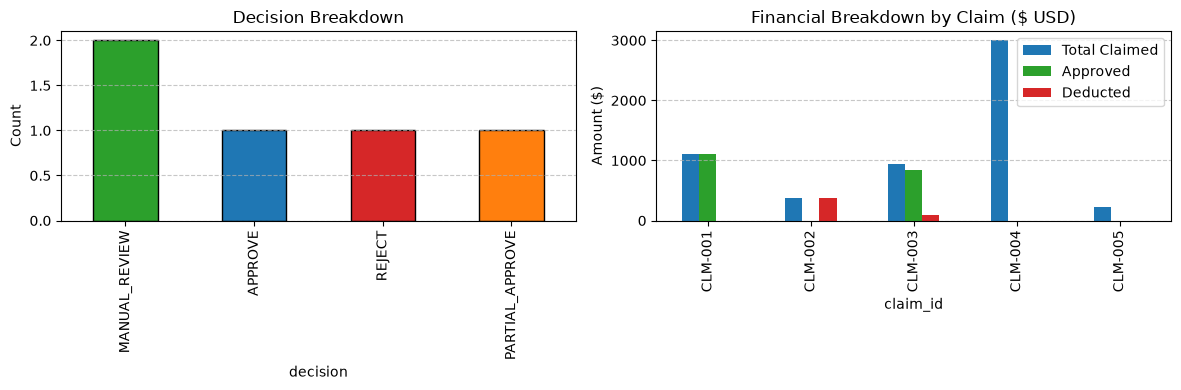

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame(claim_results)

print("=" * 60)
print("## Dashboard: Travel Reimbursement Claim Outcomes")
print("=" * 60)

# Display tabular breakdown (Updated to match Pydantic field 'total_claimed')
display_cols = ["claim_id", "decision", "total_claimed", "approved_amount", "deducted_amount", "policy_refs"]
print(df_results[display_cols].to_markdown(index=False))

# Plot minimal data-driven charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Decision Distribution
df_results['decision'].value_counts().plot(
    kind='bar', color=['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'], ax=ax1, edgecolor='black'
)
ax1.set_title("Decision Breakdown")
ax1.set_ylabel("Count")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Chart 2: Approved vs Deducted Amounts (Now including total_claimed)
df_results.plot(
    x='claim_id', 
    y=['total_claimed', 'approved_amount', 'deducted_amount'], 
    kind='bar', 
    stacked=False, 
    ax=ax2, 
    color=['#1f77b4', '#2ca02c', '#d62728'] # Blue for Claimed, Green for Approved, Red for Deducted
)
ax2.set_title("Financial Breakdown by Claim ($ USD)")
ax2.set_ylabel("Amount ($)")
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.legend(["Total Claimed", "Approved", "Deducted"])

plt.tight_layout()
plt.savefig("UI_SS_1.png")  # Saving Report
plt.show()